# PyWake AEP combined with cost model to optimize over NPV

The example is fictional and only meant to showcase the usage rather than represent reality. That being said, OPEX here will be expressed as a function of turbine AEPs. The optimizatino will take NVP as an objective function, which depends on OPEX. Design variables in this case is turbine coordinates in a farm.

### PyWake Simulation Setup



In [2]:
import numpy as np  # fmt: skip
import xarray as xr
from py_wake.examples.data.hornsrev1 import V80
from py_wake.literature.gaussian_models import Bastankhah_PorteAgel_2014
from py_wake.site import XRSite
from scipy.optimize import minimize
from costmodels import NRELCostModel
from costmodels.units import Quant

np.random.seed(42)
HOURS_IN_YEAR = 8760
ws = np.random.rand(HOURS_IN_YEAR) * 25 + 4
wd = np.random.rand(HOURS_IN_YEAR) * 360
eprice = np.random.rand(HOURS_IN_YEAR) * 0.05 + 0.1
time = np.arange(HOURS_IN_YEAR)
ds_time = xr.Dataset(
    data_vars={
        "WS": (["time"], ws),
        "WD": (["time"], wd),
    },
    coords={"time": time},
)
ds_time["P"] = 1
ds_time["TI"] = 0.1
site = XRSite(ds=ds_time)
np.testing.assert_allclose(site.ds.P.sum().item(), 1.0)

windTurbines = V80()
wfm = Bastankhah_PorteAgel_2014(site, windTurbines, k=0.0324555)

x, y = np.meshgrid(np.linspace(0, 500, 4), np.linspace(0, 500, 2))
x, y = x.ravel(), y.ravel()
sim_res = wfm(x, y, time=time)
wt_aeps = sim_res.aep().sum(dim="time").values

### Cost Model Setup

In [ ]:
cm = NRELCostModel(
    machine_rating=Quant(windTurbines.power(ws=30) / 1e6, "MW"),
    rotor_diameter=windTurbines.diameter(),
    turbine_class=0,
    tower_length=windTurbines.hub_height(),
    blade_number=3,
    blade_has_carbon=True,
    max_tip_speed=80.0,
    max_efficiency=Quant(90, "%"),
    main_bearing_number=2,
    crane=True,
    eprice=eprice.mean(),
    inflation=8,
    nwt=len(x),
    lifetime=20,
)
cm_ouput = cm.run(
    aep=Quant(wt_aeps.sum(), "GWh"),
    opex=(wt_aeps).sum() * 60,  # some factor to make it reasonable
)
cm_ouput

{'capex': <Quantity(10382174.7, 'EUR * count')>,
 'opex': <Quantity(12690536.9, 'EUR')>,
 'lcoe': <Quantity(7.37180005, 'EUR / megawatt_hour')>,
 'npv': <Quantity(128815.207, 'EUR')>,
 'irr': <Quantity(8.12714468, 'percent')>}

### Optimize over NPV

Iteration limit reached    (Exit mode 9)
            Current function value: -3353679.2673232546
            Iterations: 10
            Function evaluations: 218
            Gradient evaluations: 10
 message: Iteration limit reached
 success: False
  status: 9
     fun: -3353679.2673232546
       x: [ 4.579e+02  5.320e+02 ...  3.153e+02  5.807e+02]
     nit: 10
     jac: [ 3.391e+02  2.848e+02 ...  1.812e+01  4.966e+01]
    nfev: 218
    njev: 10


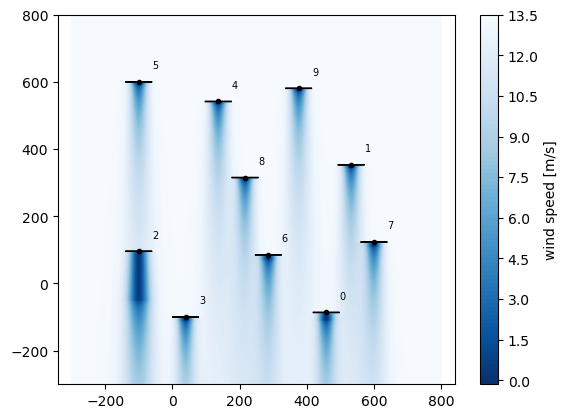

In [32]:
def objective(dv):
    wtx = dv[: len(dv) // 2]
    wty = dv[len(dv) // 2 :]
    sim_res = wfm(wtx, wty, time=time)
    wt_aeps = sim_res.aep().sum(dim="time").values
    npv = (
        cm.run(
            aep=Quant(wt_aeps.sum() * 1000, "MWh"),
            opex=(wt_aeps).sum() * 60,
        )["npv"]
        .to_base_units()
        .m
    )
    return -npv


def spacing_constraint_between_turbines(dv):
    wtx = dv[: len(dv) // 2]
    wty = dv[len(dv) // 2 :]
    min_distance = 3 * windTurbines.diameter()
    n_turbines = len(wtx)
    constraints = []
    for i in range(n_turbines):
        for j in range(i + 1, n_turbines):
            dist = np.sqrt((wtx[i] - wtx[j]) ** 2 + (wty[i] - wty[j]) ** 2)
            constraints.append(dist - min_distance)
    return np.array(constraints)


x0 = np.random.rand(10) * 500
y0 = np.random.rand(10) * 500
res = minimize(
    objective,
    np.array([x0, y0]).reshape(-1),
    method="SLSQP",
    options={"maxiter": 10, "disp": True, "ftol": 1e-8},
    constraints={"type": "ineq", "fun": spacing_constraint_between_turbines},
    bounds=[(-100, 600)] * 2 * len(x0),
)
print(res)

opt_x = res.x[: len(res.x) // 2]
opt_y = res.x[len(res.x) // 2 :]
flow_map = wfm(opt_x, opt_y, time=[0]).flow_map()
flow_map.plot_wake_map()
import matplotlib.pyplot as plt  # fmt:skip
plt.show()